**Using LSTMs for predicting the price of stocks of IBM for the year 2017**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error

In [2]:
def plot_predictions(test, predicted):
    plt.plot(test, color="red", label="Real IBM Stock Price")
    plt.plot(predicted, color="blue", label="Predicted IBM Stock Price")
    plt.title("IBM Stock Price Prediction")
    plt.xlabel ("Time")
    plt.ylabel ("IBM Stock Price")
    plt.legend()
    plt.show()

In [3]:
def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

In [4]:
dataset = pd.read_csv('C:/Users/oyelola Ibrahim/Desktop\IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\oyelola Ibrahim\AppData\Local\Temp\ipykernel_15604\3215145940.py:1: SyntaxWarning: invalid escape sequence '\I'
  dataset = pd.read_csv('C:/Users/oyelola Ibrahim/Desktop\IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])


,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [5]:
# Checking for missing values
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

In [6]:
training_set

array([[41.22],
       [41.9 ],
       [41.73],
       ...,
       [39.22],
       [38.93],
       [39.  ]], shape=(2768, 1))

In [7]:
test_set

array([[39.18],
       [40.25],
       [41.37],
       [41.34],
       [41.66],
       [42.37],
       [42.59],
       [42.46],
       [42.46],
       [42.18],
       [42.15],
       [42.19],
       [42.54],
       [42.45],
       [44.22],
       [45.  ],
       [45.08],
       [44.71],
       [44.22],
       [44.15],
       [44.26],
       [44.  ],
       [43.99],
       [44.53],
       [44.59],
       [45.19],
       [45.24],
       [45.23],
       [45.57],
       [45.58],
       [46.72],
       [45.69],
       [45.34],
       [45.61],
       [46.34],
       [46.14],
       [45.55],
       [45.74],
       [45.75],
       [46.41],
       [46.13],
       [46.  ],
       [45.69],
       [45.92],
       [46.19],
       [46.12],
       [46.2 ],
       [47.  ],
       [46.76],
       [46.55],
       [46.62],
       [46.9 ],
       [47.16],
       [47.19],
       [46.14],
       [46.78],
       [46.86],
       [46.48],
       [46.76],
       [46.84],
       [47.04],
       [46.7 ],
       [

In [8]:
dataset["High"][:'2016'][:10]

Date
2006-01-03    41.22
2006-01-04    41.90
2006-01-05    41.73
2006-01-06    43.57
2006-01-09    43.66
2006-01-10    43.34
2006-01-11    42.31
2006-01-12    41.99
2006-01-13    41.08
2006-01-17    40.39
Name: High, dtype: float64

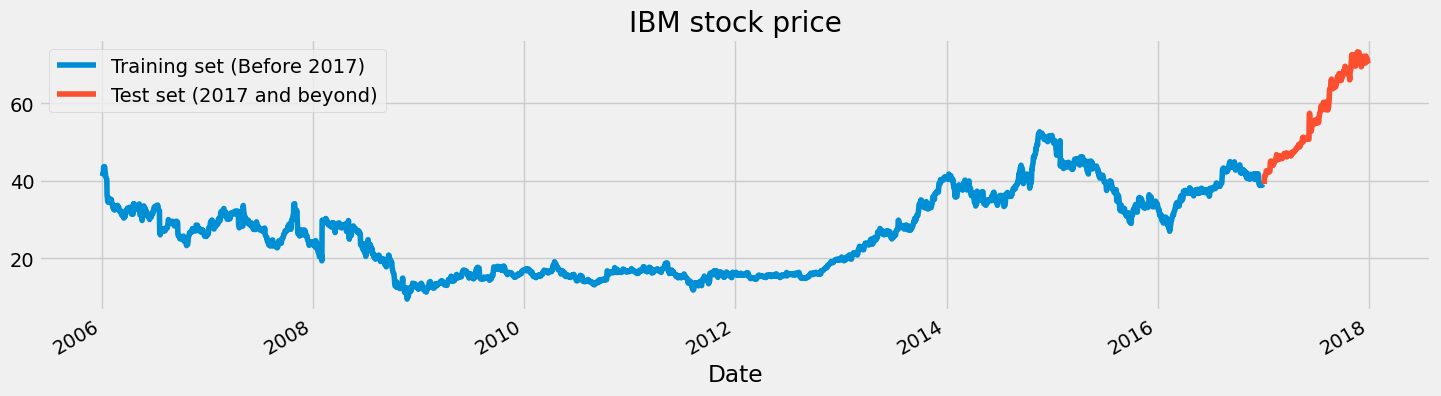

In [9]:
# We have chosen 'High' attribute for prices. Let's see what it looks like
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [10]:
# Scaling the training set
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [11]:
training_set_scaled

array([[0.73574409],
       [0.75150672],
       [0.74756606],
       ...,
       [0.6893834 ],
       [0.6826611 ],
       [0.68428373]], shape=(2768, 1))

In [12]:
print(training_set.shape)
print(training_set_scaled.shape)

(2768, 1)
(2768, 1)


In [13]:
# Since LSTMs store long term memory state, we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements 
X_train = []
y_train = []
for i in range(60,2768):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [14]:
X_train.shape

(2708, 60)

In [15]:
y_train.shape

(2708,)

In [16]:
# Reshaping X_train for efficient modelling
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

In [17]:
X_train.shape

(2708, 60, 1)

In [18]:
# The LSTM architecture
regressor = Sequential()
# First LSTM layer with Dropout regularisation
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2))
# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Third LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Fourth LSTM layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
# The output layer
regressor.add(Dense(units=1))

# Compiling the RNN
regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
# Fitting to the training set
regressor.fit(X_train,y_train,epochs=50,batch_size=32)

C:\Users\oyelola Ibrahim\Desktop\my deep learning project\ANN_with_MNISTDATA\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - loss: 0.0132
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 0.0072
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - loss: 0.0057
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 0.0049
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0045
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0043
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0037
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - loss: 0.0036
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - loss: 0.0034
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - loss: 0.0029
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 0.0031
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0027
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 0.0026
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0024
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - l

In [19]:
regressor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,104 (555.10 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 71,053 (277.55 KB)

In [20]:
#%pip install pydot

In [21]:
#This code will give graphical representation
import tensorflow as tf
tf.keras.utils.plot_model(regressor)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [22]:
# Now to get the test set ready in a similar way as the training set.
# The following has been done so for 60 entires of test set have 60 previous values which is impossible to get unless we take the whole 
# 'High' attribute data for processing
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs  = sc.transform(inputs)

In [23]:
print(len(dataset_total))
print(len(test_set))

3019
251


In [24]:
inputs[:10]

array([[0.79601298],
       [0.79276773],
       [0.80180807],
       [0.80203987],
       [0.77190542],
       [0.75567918],
       [0.75961984],
       [0.75243394],
       [0.76773296],
       [0.77561428]])

In [25]:
dataset_total[:10].values

array([41.22, 41.9 , 41.73, 43.57, 43.66, 43.34, 42.31, 41.99, 41.08,
       40.39])

In [26]:
dataset_total[len(dataset_total) - len(test_set) -60:].values

array([43.82, 43.68, 44.07, 44.08, 42.78, 42.08, 42.25, 41.94, 42.6 ,
       42.94, 42.69, 42.2 , 42.68, 42.75, 42.44, 42.49, 42.22, 42.16,
       41.34, 42.16, 40.75, 40.67, 41.23, 41.28, 41.39, 41.65, 40.52,
       40.39, 40.45, 41.05, 41.65, 41.65, 41.48, 41.4 , 40.98, 41.08,
       41.7 , 41.83, 41.67, 41.04, 40.32, 40.39, 40.42, 40.57, 41.6 ,
       41.8 , 41.53, 41.79, 41.53, 40.  , 39.22, 38.79, 39.18, 39.32,
       38.79, 38.81, 39.06, 39.22, 38.93, 39.  , 39.18, 40.25, 41.37,
       41.34, 41.66, 42.37, 42.59, 42.46, 42.46, 42.18, 42.15, 42.19,
       42.54, 42.45, 44.22, 45.  , 45.08, 44.71, 44.22, 44.15, 44.26,
       44.  , 43.99, 44.53, 44.59, 45.19, 45.24, 45.23, 45.57, 45.58,
       46.72, 45.69, 45.34, 45.61, 46.34, 46.14, 45.55, 45.74, 45.75,
       46.41, 46.13, 46.  , 45.69, 45.92, 46.19, 46.12, 46.2 , 47.  ,
       46.76, 46.55, 46.62, 46.9 , 47.16, 47.19, 46.14, 46.78, 46.86,
       46.48, 46.76, 46.84, 47.04, 46.7 , 46.85, 46.47, 46.92, 46.43,
       46.53, 47.42,

In [27]:
# Preparing X_test and predicting the prices
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 392ms/step


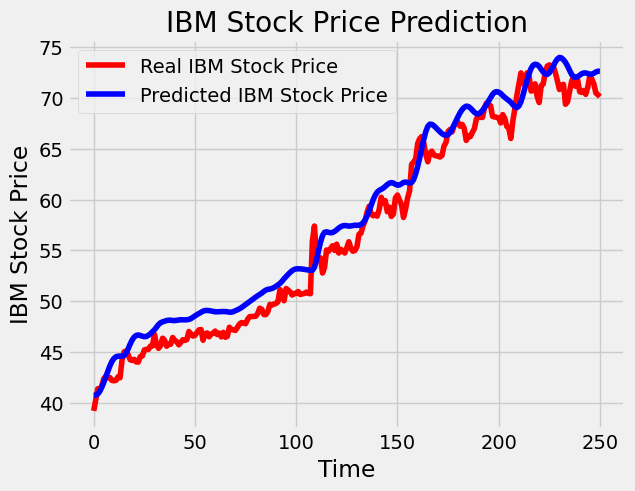

In [28]:
# Visualizing the results for LSTM
plot_predictions(test_set,predicted_stock_price)

In [29]:
# Evaluating our model
return_rmse(test_set,predicted_stock_price)

The root mean squared error is 1.941210261474009.


**Gated Recurrent Unit (GRU)**

In [30]:
# The GRU architecture
regressorGRU = Sequential()
# First GRU layer with Dropout regularisation
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Second GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Third GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Fourth GRU layer
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# The output layer
regressorGRU.add(Dense(units=1))

C:\Users\oyelola Ibrahim\Desktop\my deep learning project\ANN_with_MNISTDATA\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
# Compiling the RNN
regressorGRU.compile(optimizer=SGD(learning_rate=0.01, decay=1e-7, momentum=0.9, nesterov=False),loss='mean_squared_error')
# Fitting to the training set
regressorGRU.fit(X_train,y_train,epochs=3,batch_size=150)

C:\Users\oyelola Ibrahim\Desktop\my deep learning project\ANN_with_MNISTDATA\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 338ms/step - loss: 0.0949
Epoch 2/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 307ms/step - loss: 0.0510
Epoch 3/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 290ms/step - loss: 0.0289


In [32]:
regressorGRU.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 60, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 60, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,804 (421.11 KB)

 Trainable params: 53,901 (210.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 53,903 (210.56 KB)

In [33]:
# Preparing X_test and predicting the prices
X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 323ms/step


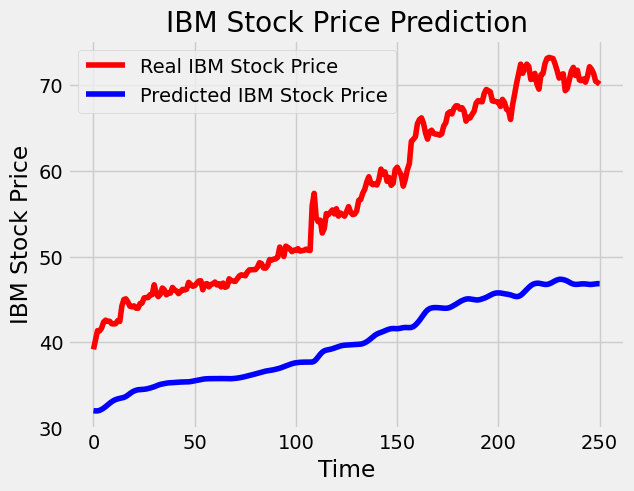

In [34]:
# Visualizing the results for GRU
plot_predictions(test_set,GRU_predicted_stock_price)

In [35]:
# Evaluating GRU
return_rmse(test_set,GRU_predicted_stock_price)

The root mean squared error is 17.73856618733402.
